## Logistics Regression Model 

In [1]:
!pip install pandas matplotlib seaborn numpy

In [2]:
# Step 1: Import Required Lib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Step 2: Load the datasets
df = pd.read_csv(r"C:\Users\anilr\Downloads\Churn_prediction\customer_churn.csv")

In [4]:
# Step 3: Data Exploration
df.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1000 non-null   int64  
 1   income                 951 non-null    float64
 2   credit_score           950 non-null    float64
 3   transactions_month     1000 non-null   int64  
 4   avg_purchase_value     950 non-null    float64
 5   days_since_last_login  1000 non-null   int64  
 6   tenure_months          1000 non-null   int64  
 7   num_products           1000 non-null   int64  
 8   gender                 1000 non-null   str    
 9   region                 1000 non-null   str    
 10  churn                  1000 non-null   int64  
dtypes: float64(3), int64(6), str(2)
memory usage: 86.1 KB


In [6]:
df.isnull().sum()

age                       0
income                   49
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

In [7]:
df.describe()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,churn
count,1000.00000,951.000000,950.000000,1000.000000,950.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,55354.417513,651.422837,29.842000,119.301574,182.155000,60.394000,3.129000,0.517000
std,14.99103,32708.500386,68.271995,5.453511,39.619144,104.205824,34.163166,1.410088,0.499961
min,18.00000,7271.860691,444.172796,15.000000,-7.068153,0.000000,1.000000,1.000000,0.000000
25%,31.00000,40959.853770,605.096009,26.000000,93.330104,88.000000,31.000000,2.000000,0.000000
50%,44.00000,51298.846812,650.746768,30.000000,119.585761,184.000000,61.000000,3.000000,1.000000
75%,56.00000,61285.465584,697.845647,33.000000,146.374081,273.250000,89.250000,4.000000,1.000000
max,69.00000,254852.478291,873.517530,49.000000,244.516408,364.000000,119.000000,5.000000,1.000000


<Axes: ylabel='tenure_months'>

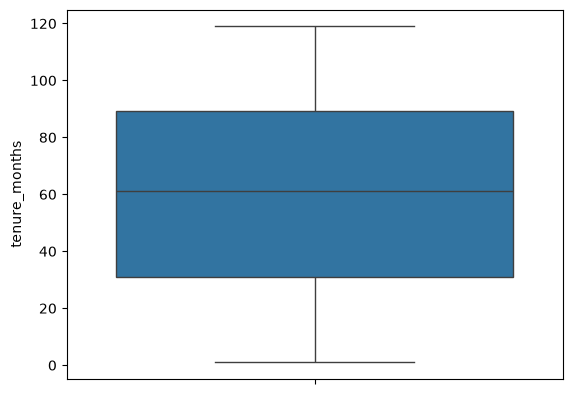

In [8]:
# make theb box plot
sns.boxplot(df['tenure_months'])


In [9]:
# Step 4: Data Preprocessing 

# handled the missing value using median of all num  columns

# 1: income
income_median =df['income'].median()
income_median = round(income_median,2)

# 2: credit_score
credit_median =round(df['credit_score'].median(),2)

# avg_purchase_value
purchase_value_med =  round(df['avg_purchase_value'].median(),2)

# handled the misinng value 

# credit score 
df['credit_score'].fillna(credit_median,inplace = True)

# income
df['income'].fillna(income_median,inplace = True)

# avg_purchase_value
df['avg_purchase_value'].fillna(purchase_value_med,inplace = True)


C:\Users\anilr\AppData\Local\Temp\ipykernel_13144\2894719310.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['credit_score'].fillna(credit_median,inplace = True)
C:\Users\anilr\AppData\Local\Temp\ipykernel_13144\2894719310.py:21: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained a

0       84.828689
1      133.943805
2      114.993023
3      153.875284
4      115.391031
          ...    
995    149.322171
996     44.289513
997    132.459634
998     72.489390
999    104.107070
Name: avg_purchase_value, Length: 1000, dtype: float64

In [10]:
df.isnull().sum()
df['income'] = df['income'].fillna(df['income'].median())
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())
df['avg_purchase_value'] = df['avg_purchase_value'].fillna(df['avg_purchase_value'].median())

In [11]:
# handled the outlier 

outlier_cols  = ['income','credit_score','avg_purchase_value']

for col in outlier_cols:

    # find the Q1 and Q3
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)

    # find the IQR
    IQR = Q3 - Q1

    # Find the upper bound and lower bound 
    lower_bound =  Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    # handled the outlier
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)



<Axes: ylabel='credit_score'>

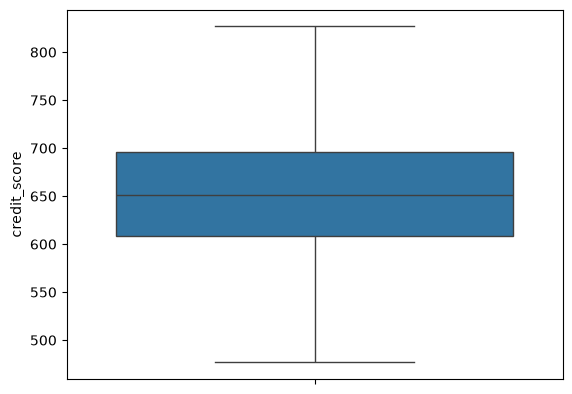

In [12]:
sns.boxplot(df['credit_score'])

In [13]:
# handled cat columns 

df['gender'].replace({'Male':1,'Female':0},inplace = True)


C:\Users\anilr\AppData\Local\Temp\ipykernel_13144\4242939502.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['gender'].replace({'Male':1,'Female':0},inplace = True)


0      1
1      0
2      1
3      1
4      1
      ..
995    1
996    1
997    1
998    1
999    0
Name: gender, Length: 1000, dtype: object

In [14]:
df["gender"] = df["gender"].str.strip().str.title()

df["gender"] = df["gender"].map({
    "Male": 1,
    "Female": 0
})

In [15]:
# drop the region
df.drop('region',axis= True , inplace= True)

In [16]:
# Step 5: Divide into X and Y 

X = df.drop('churn',axis=1)
y = df['churn']

In [17]:
# Step 6: Splitting datasets into train and test 
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [18]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [19]:
# Step 7: Model building 

from sklearn.linear_model import LogisticRegression

# create the instance of model 
LR  = LogisticRegression()

# train the model 
model  = LR.fit(X_train,y_train)

# prediction on testing 
y_pred  = model.predict(X_test)

c:\Users\anilr\Downloads\Churn_prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
# Step 8: Model Evaluation metrics

from sklearn.metrics import accuracy_score

# find accuracy
ac = accuracy_score(y_test,y_pred)
print("Accuracy of model",ac)

Accuracy of model 0.54
